In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

if os.environ["OPENAI_API_KEY"] is None:
    raise ValueError("OPENAI_API_KEY environment variable not set.")
else:
    print("OPENAI_API_KEY environment variable is set.")


OPENAI_API_KEY environment variable is set.


In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")


response = llm.invoke("Hello how are you?")
response.content

"Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

## Tools

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool
import subprocess
import sys

search_tool = DuckDuckGoSearchRun()


## Custom Tool: Python Execution

@tool
def run_python(code: str) -> str:
    """ Run python code and return stdout and stderr. Use code for calculation and data processing. No file/network access. """
    try:
        result = subprocess.run([sys.executable,"-c",code],
                       capture_output=True,text=True,timeout=10,cwd= os.getcwd())

        out = result.stdout or ""
        err = result.stderr or ""

        if result.returncode!=0:
            return f"STDERR:{err}\n STDOUT:{out}"
        return out.strip()
    
    except Exception as e:
        return f"Exception Raised: {e}"
    

RESEARCHER_TOOL = [search_tool]
CODER_TOOL = [run_python]





## Multi- Agent Graph

In [11]:
from typing import TypedDict
from langchain_core.messages import HumanMessage, SystemMessage,AnyMessage,AIMessage
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph,START,END,MessagesState,add_messages
from langgraph.prebuilt import ToolNode,tools_condition,create_react_agent
from typing import TypedDict,Annotated,Literal
from langsmith import Client
from pydantic import BaseModel,Field
from langgraph.types import Command


In [7]:
class State(MessagesState):
    next : str

class Router(TypedDict):
    next: Literal["researcher","coder","FINISH"]


## Worker nodes
MEMBERS = ["researcher","coder"]

In [25]:
def supervisor_node(state: State) -> Command:
    """ Decide which workers acts next; return the command to router and state """
    SUPERVISOR_PROMPT = """ Your are a supervior managing these workers:{MEMBERS}
       Give the user request and the conversation histories decide which worker should act next .
        - researcher: for websearch and facts checks.
        - coder : for writing and executing the python code. 
        When the task is done or the user message is neither of the above respond with FINISH"""
    message = [SystemMessage(content=SUPERVISOR_PROMPT)] + list(state["messages"])
    llm_supervisor = llm.with_structured_output(Router)
    response = llm_supervisor.invoke(message)
    # with_structured_output(TypedDict) returns a dict, not an object
    goto = response["next"] 
    if goto == "FINISH":
        goto = "__end__"
    return Command(update={"next":goto}, goto=goto)

## https://reference.langchain.com/python/langgraph/types/Command 

In [26]:
def research_node(state:State)-> Command:
    """ Run the reasercher ReAct agent (search tool) then hand it back to the supervisor   """

    agent = create_react_agent(llm,tools=RESEARCHER_TOOL,prompt = "Your are a researcher. Use websearch to find out the uptodate information. Don't do any programming or caluculation")
    result = agent.invoke(state)
    last_message = result["messages"][-1].content if result["messages"] else "no response"
    return Command(update={"messages":[HumanMessage(content=last_message, name="researcher")]}, goto="supervisor")


def coder_node(state:State)-> Command:
    """ Run the Coder ReAct agent (run_python tool) then hand it back to the supervisor   """

    agent = create_react_agent(llm,tools=CODER_TOOL,prompt = "Your are a coder. Write and run the python code to the user question. Use the run_python tool to execute it . Don't search the web. ")
    result = agent.invoke(state)
    last_message = result["messages"][-1].content if result["messages"] else "no response"
    return Command(update={"messages":[HumanMessage(content=last_message, name="coder")]}, goto="supervisor")





In [27]:
def route_after_supervsior(state:State) -> str:
    return state.get("next","__end__")

In [28]:
workflow = StateGraph(State)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("researcher", research_node)   # name must match Router output and edges
workflow.add_node("coder", coder_node)           # name must match Router output and edges

workflow.add_edge(START, "supervisor")
workflow.add_conditional_edges("supervisor", route_after_supervsior, {"researcher": "researcher", "coder": "coder", "__end__": END})
workflow.add_edge("researcher", "supervisor")
workflow.add_edge("coder", "supervisor")


In [29]:
app = workflow.compile()

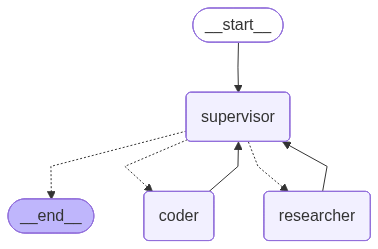

In [30]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
# Example 1: question that may use researcher
result = app.invoke({"messages": [("user", "What is the current population of Tokyo? Answer in 2 sentences.")]})

/var/folders/2h/sjyl9z_s50v8pl2446pvqjrw0000gn/T/ipykernel_5311/782521055.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm,tools=RESEARCHER_TOOL,prompt = "Your are a researcher. Use websearch to find out the uptodate information. Don't do any programming or caluculation")


In [32]:
result

{'messages': [HumanMessage(content='What is the current population of Tokyo? Answer in 2 sentences.', additional_kwargs={}, response_metadata={}, id='dd7d1c2a-423f-4fc7-be85-ac57359e2e04'),
  HumanMessage(content='The current population of Tokyo in 2023 is estimated to be approximately 35.8 million. This marks a slight increase from the 35.6 million reported in 2022.', additional_kwargs={}, response_metadata={}, name='researcher', id='cf431fe0-e6e5-491d-a993-89c7f99a498b')],
 'next': '__end__'}

In [33]:
# Example 1: question that may use researcher
result = app.invoke({"messages": [("user", "write a python code to compute first 5 fibonacci numbers and run it")]})

/var/folders/2h/sjyl9z_s50v8pl2446pvqjrw0000gn/T/ipykernel_5311/782521055.py:13: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm,tools=CODER_TOOL,prompt = "Your are a coder. Write and run the python code to the user question. Use the run_python tool to execute it . Don't search the web. ")


In [34]:
result

{'messages': [HumanMessage(content='write a python code to compute first 5 fibonacci numbers and run it', additional_kwargs={}, response_metadata={}, id='3ce1970f-2fb1-4a7c-92f3-c2e18be29d2b'),
  HumanMessage(content='The first 5 Fibonacci numbers are: [0, 1, 1, 2, 3].', additional_kwargs={}, response_metadata={}, name='coder', id='cbb7cee3-499c-4cf8-ac58-05d3df875e54')],
 'next': '__end__'}